In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3

In [2]:
def scientific_latex(value):
    exponent = int(np.floor(np.log10(abs(value))))
    mantissa = value / 10**exponent
    return rf"${mantissa:.1f}\times10^{{{exponent}}}$"

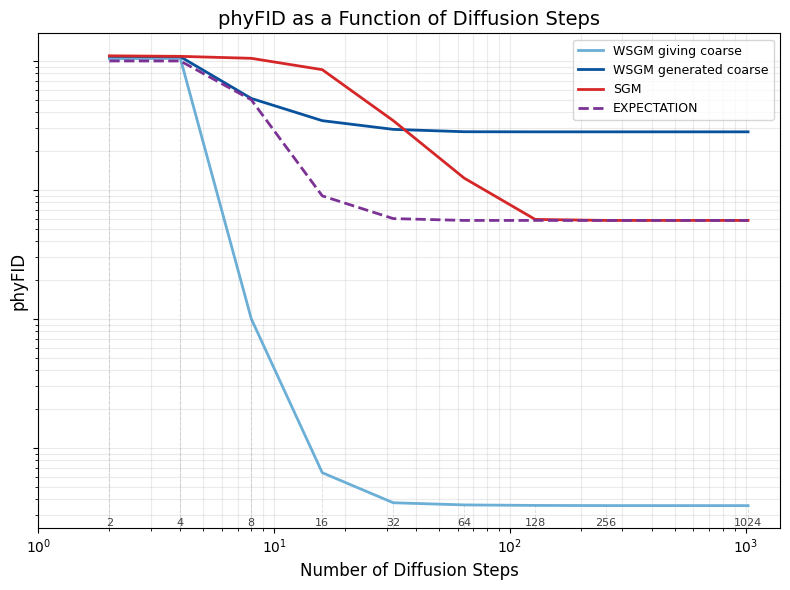

In [3]:
FID_f_STEPS = "FID_fonction_de_STEPS_data_vrai.csv"

fid_df = pd.read_csv(FID_f_STEPS)
fid_df.columns = fid_df.columns.str.strip()

step_column = "steps"
if step_column not in fid_df.columns:
    raise ValueError(f"Missing required column: {step_column}")

fid_df[step_column] = pd.to_numeric(fid_df[step_column], errors="coerce")
fid_df = fid_df.dropna(subset=[step_column]).sort_values(step_column)

metric_columns = [column for column in fid_df.columns if column != step_column]
fig, ax = plt.subplots(figsize=(8, 6))

series_styles = {
    "WSGM giving coarse": {"color": "#6baed6", "linestyle": "-"},
    "WSGM generated coarse": {"color": "#08519c", "linestyle": "-"},
    "SGM": {"color": "#d62728", "linestyle": "-"},
    "EXPECTATION": {"color": "#7b3294", "linestyle": "--"},
}

plotted_series = []
skipped_columns = []
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for idx, column in enumerate(metric_columns):
    values = pd.to_numeric(fid_df[column], errors="coerce")
    steps = fid_df[step_column].to_numpy(dtype=float)
    fid_values = values.to_numpy(dtype=float)
    valid = np.isfinite(steps) & np.isfinite(fid_values) & (steps > 0) & (fid_values > 0)

    if not np.any(valid):
        skipped_columns.append(column)
        continue

    style = series_styles.get(column, {"color": color_cycle[idx % len(color_cycle)], "linestyle": "-"})
    ax.plot(
        steps[valid],
        fid_values[valid],
        linestyle=style["linestyle"],
        color=style["color"],
        linewidth=2.0,
        label=column,
    )
    plotted_series.append((steps[valid], fid_values[valid], style["color"]))

if not plotted_series:
    raise ValueError("No finite positive FID values available for log-scale plotting.")

if skipped_columns:
    print("Skipped columns without finite positive values:", ", ".join(skipped_columns))

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Number of Diffusion Steps", fontsize=12)
ax.set_ylabel("phyFID", fontsize=12)
ax.tick_params(axis="y", which="both", labelleft=False)
ax.set_title("phyFID as a Function of Diffusion Steps", fontsize=14)

ax.set_xlim(left=1)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

min_dx_log = 0.08
annotated_x = []

for steps, fid_values, color in plotted_series:
    for x, y in zip(steps, fid_values):
        draw_x = all(
            abs(np.log10(x) - np.log10(x_old)) > min_dx_log
            for x_old in annotated_x
        )

        if draw_x:
            ax.vlines(x, ymin, y, color="0.4", linestyle="--", linewidth=0.7, alpha=0.2)
            ax.annotate(
                f"{x:g}",
                xy=(x, ymin),
                xytext=(0, 7),
                textcoords="offset points",
                color="0.25",
                fontsize=8,
                ha="center",
                va="top",
                annotation_clip=False,
            )
            annotated_x.append(x)

ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()
report_figure_dir = Path.cwd().parents[1] / "doc" / "BDRPReportTemplate" / "figures" / "ch5"
report_figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(report_figure_dir / "phyfid_vs_steps.png", bbox_inches="tight", dpi=300)
plt.show()


---
## Synthèse visuelle et physique : SGM, WSGM oracle et cascade complète

Le cas oracle emploie le coarse réel et isole donc la qualité conditionnelle des niveaux de détail. La cascade complète échantillonne également le coarse ; son écart mesure l'accumulation d'erreur. Les métriques sont calculées sur 1 000 images avec le même split validation/hold-out.

In [4]:
# import sys
# import torch

# project_root = next(
#     candidate for candidate in [Path.cwd(), *Path.cwd().parents]
#     if (candidate / "data" / "RT64").exists()
# )
# sys.path.insert(0, str(project_root / "analyse_reslutat"))
# from result_utils import (
#     compare_result_metrics,
#     plot_image_grid,
#     plot_spectral_energy,
#     print_result_metrics,
#     reconstruct_oracle_cascade,
#     to_unit_interval,
# )

# real = torch.load(project_root / "data/RT64/processed/validation.pt", weights_only=True).float() / 255.0
# real_coarse = torch.load(project_root / "data/RT64/processed/j2_validation.pt", weights_only=True).float()[:, :1]
# baseline = to_unit_interval(torch.load(project_root / "outputs/generated/64dataset_e-4_s1024.pt", weights_only=True))
# oracle_root = project_root / "outputs/generated/cascade_sgm_1024"
# full_root = project_root / "outputs/generated/cascade_sgm_hcirc_blurpool_eps00001"
# oracle_j2 = torch.load(oracle_root / "j2_generated_coefficients.pt", weights_only=True)
# oracle_j1 = torch.load(oracle_root / "j1_generated_coefficients.pt", weights_only=True)
# oracle = reconstruct_oracle_cascade(real_coarse, oracle_j2, oracle_j1)
# full = torch.load(full_root / "generated_images.pt", weights_only=True)
# encoder = project_root / "outputs/phyFID/64phyfid_encoder.pt"

# results = {
#     "Baseline SGM": compare_result_metrics(real, baseline, encoder),
#     "WSGM oracle": compare_result_metrics(real, oracle, encoder),
#     "WSGM cascade complète": compare_result_metrics(real, full, encoder),
# }
# for label, metrics in results.items():
#     print_result_metrics(label, metrics)

# plot_image_grid(baseline, n=16, cols=4, seed=16, title="Baseline SGM — images générées (4×4)")
# plot_image_grid(oracle, n=16, cols=4, seed=16, title="WSGM oracle — coarse parfait (4×4)")
# plot_image_grid(full, n=16, cols=4, seed=16, title="WSGM cascade complète (4×4)")
# plot_spectral_energy(real[:1000], oracle[:1000], title="WSGM oracle — spectre d'énergie")
# plot_spectral_energy(real[:1000], full[:1000], title="WSGM cascade complète — spectre d'énergie")

## All generated ensembles — report figure

This figure juxtaposes the three generated ensembles as three reproducible 4x4 blocks. The reference-coarse WSGM is labelled as a controlled diagnostic, because its coarse representation comes from validation data.


In [5]:
import sys
import torch

project_root = Path.cwd().parents[1]
analysis_dir = project_root / "analyse_reslutat"
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from result_utils import plot_generation_comparison, reconstruct_oracle_cascade, save_figure

baseline_generated = torch.load(
    project_root / "outputs" / "generated" / "64dataset_e-4_s1024.pt",
    map_location="cpu",
    weights_only=True,
)
wavelet_output_dir = project_root / "outputs" / "generated" / "cascade_sgm_hcirc_blurpool_eps00001"
reference_coarse = torch.load(
    project_root / "data" / "RT64" / "processed" / "j2_validation.pt",
    map_location="cpu",
    weights_only=True,
)[:, :1]
wavelet_j2 = torch.load(
    wavelet_output_dir / "j2_generated_coefficients.pt",
    map_location="cpu",
    weights_only=True,
)
wavelet_j1 = torch.load(
    wavelet_output_dir / "j1_generated_coefficients.pt",
    map_location="cpu",
    weights_only=True,
)
wavelet_generated_coarse = torch.load(
    wavelet_output_dir / "generated_images.pt",
    map_location="cpu",
    weights_only=True,
)
wavelet_reference_coarse = reconstruct_oracle_cascade(reference_coarse, wavelet_j2, wavelet_j1)

fig, _ = plot_generation_comparison(
    [
        ("Baseline SGM", baseline_generated),
        ("WSGM: reference coarse", wavelet_reference_coarse),
        ("WSGM: generated coarse", wavelet_generated_coarse),
    ],
    n=16,
    cols=4,
    seed=16,
    cmap="gray",
    title="Generated RTI ensembles: direct diffusion and wavelet cascades",
)
save_figure(fig, project_root / "doc" / "BDRPReportTemplate" / "figures" / "ch5" / "generated_ensembles_comparison.png")
plt.show()


ModuleNotFoundError: No module named 'lib'